In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
df = pd.read_csv('bioinformatics_visualization_practice_dataset.csv')
df.head()

,Patient_ID,Age,Gender,Disease_Status,Gene_A_Expression,Gene_B_Expression,Gene_C_Expression,Blood_Pressure,Glucose,Mutation_A,Mutation_B,Mutation_C
0,P1001,60,Male,At Risk,5.55,5.97,4.94,148,115.0,Yes,Yes,Yes
1,P1002,50,Female,Healthy,4.43,5.54,3.40,137,102.0,No,Yes,No
2,P1003,36,Male,Disease,8.65,8.22,4.44,147,102.0,No,Yes,No
3,P1004,64,Female,Healthy,3.74,5.73,4.31,141,93.0,Yes,Yes,No
4,P1005,29,Male,Disease,8.17,7.84,3.23,110,111.0,Yes,No,No


In [11]:
noof = df.shape
print("number of rows: ", noof[0])
print("number of columns: ", noof[1])
print("shape: ", noof)

number of rows:  40
number of columns:  12
shape:  (40, 12)


In [24]:
columns = df.columns

for i in range(noof[1]):
    print(columns[i])

Patient_ID
Age
Gender
Disease_Status
Gene_A_Expression
Gene_B_Expression
Gene_C_Expression
Blood_Pressure
Glucose
Mutation_A
Mutation_B
Mutation_C


In [36]:
dtypes = df.dtypes
print(dtypes)

Patient_ID            object
Age                    int64
Gender                object
Disease_Status        object
Gene_A_Expression    float64
Gene_B_Expression    float64
Gene_C_Expression    float64
Blood_Pressure         int64
Glucose              float64
Mutation_A            object
Mutation_B            object
Mutation_C            object
dtype: object


In [40]:
df.isnull().sum()

Patient_ID           0
Age                  0
Gender               0
Disease_Status       0
Gene_A_Expression    0
Gene_B_Expression    1
Gene_C_Expression    0
Blood_Pressure       0
Glucose              1
Mutation_A           0
Mutation_B           0
Mutation_C           0
dtype: int64

In [46]:
df.columns[df.isnull().any()]

Index(['Gene_B_Expression', 'Glucose'], dtype='object')

In [48]:
disease_count = df['Disease_Status'].value_counts()
print(disease_count)

Disease_Status
Disease    16
At Risk    12
Healthy    12
Name: count, dtype: int64


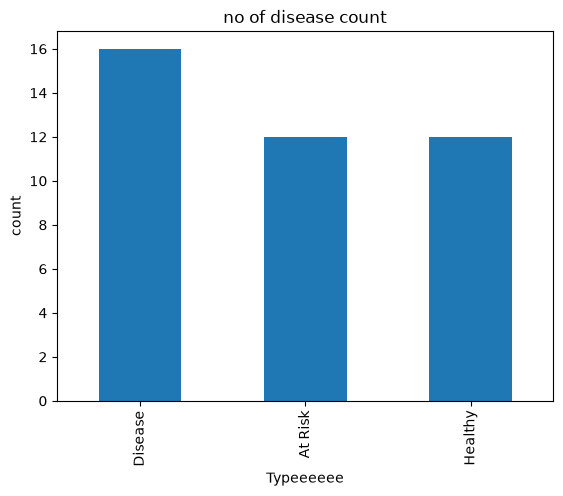

In [52]:
disease_count.plot(kind = 'bar')
plt.xlabel("Typeeeeee")
plt.ylabel("count")
plt.title("no of disease count")
plt.show()

In [55]:
print(f"{disease_count.idxmax()} : {disease_count.max()}")

Disease : 16


In [61]:
g = df.groupby('Disease_Status')[['Gene_A_Expression','Gene_B_Expression','Gene_C_Expression']].mean()
print(g)

                Gene_A_Expression  Gene_B_Expression  Gene_C_Expression
Disease_Status                                                         
At Risk                  5.907500           6.415833           4.177500
Disease                  7.930000           7.478000           3.940000
Healthy                  4.271667           5.912500           5.045833


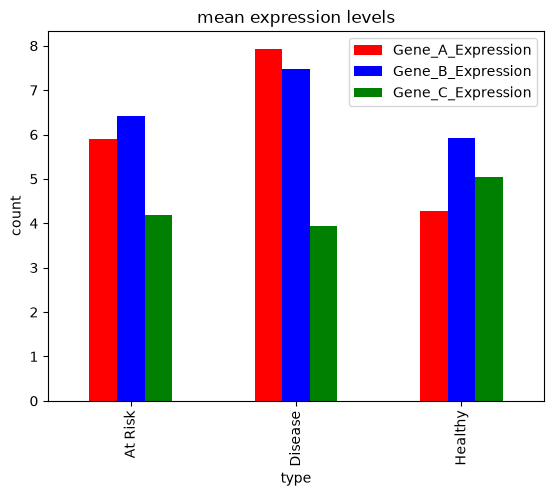

In [82]:
g.plot(kind = 'bar', color=['red', 'blue', 'green'])
plt.title('mean expression levels')
# plt.legend(df[['Gene_A_Expression', 'Gene_B_Expression', 'Gene_C_Expression']])
plt.xlabel('type')
plt.ylabel('count')
plt.show()

In [94]:
print(f"higher gene: {g.mean(axis = 1).idxmin()}")

higher gene: Healthy


C:\Users\chath\AppData\Local\Temp\ipykernel_9556\3313195809.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


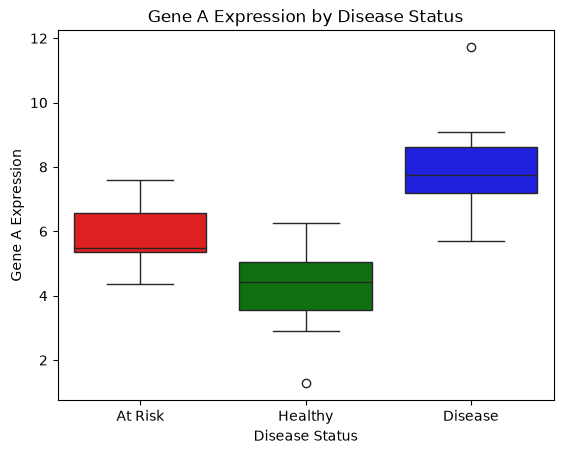

In [107]:
sns.boxplot(
    data=df,
    x="Disease_Status",
    y="Gene_A_Expression",
    palette=["red", "green", "blue"]
)

plt.title("Gene A Expression by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Gene A Expression")
plt.show()

In [118]:
adoh = df.groupby('Disease_Status')['Gene_A_Expression'].median()
median = df.groupby("Disease_Status")[
    "Gene_A_Expression"
].median()

print(f"highest median gene a expression: {median.idxmax}")

highest median gene a expression: <bound method Series.idxmax of Disease_Status
At Risk    5.495
Disease    7.755
Healthy    4.415
Name: Gene_A_Expression, dtype: float64>


C:\Users\chath\AppData\Local\Temp\ipykernel_9556\3491454446.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


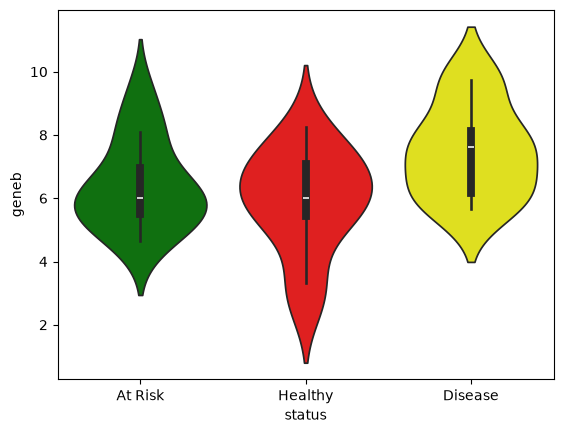

In [126]:
sns.violinplot(
    data = df,
    x = 'Disease_Status',
    y = 'Gene_B_Expression',
    palette = ['green', 'red', 'yellow']
)

plt.ylabel('geneb')
plt.xlabel('status')
plt.show()

In [133]:
mean_b = df.groupby('Disease_Status')['Gene_B_Expression'].mean()
print(f"higher is : {mean_b.idxmax()}")


higher is : Disease


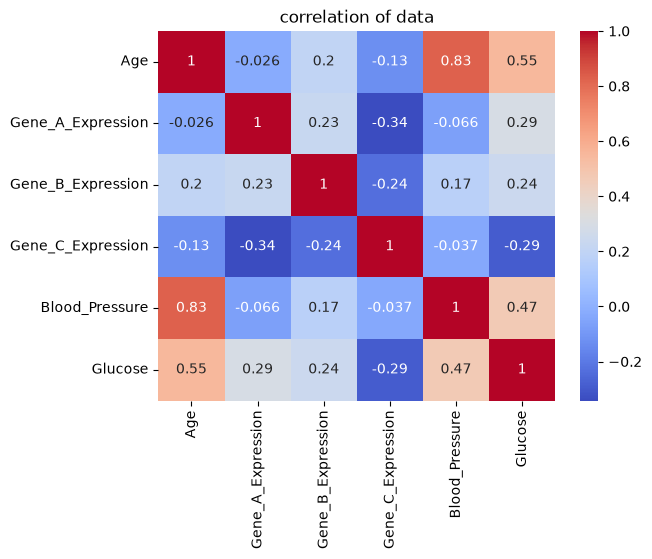

max id : ('Age', 'Blood_Pressure')
max id : 0.8272658325720097


In [144]:
columns = [
    'Age',
    'Gene_A_Expression',
    'Gene_B_Expression',
    'Gene_C_Expression',
    'Blood_Pressure',
    'Glucose'
]

corr = df[columns].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("correlation of data")
plt.show()

corr2 = corr.copy()

for i in range(len(corr2)):
    corr2.iloc[i, i] = 0

print(f"max id : { corr2.stack().idxmax() }")
print(f"max id : { corr2.stack().max() }")